# ODRM\* Classical Planner — Scalability & Memory Failure Analysis

This notebook analyzes the **ODRM\*** classical planner in grid worlds of size **70×70** and **160×160** under varying **obstacle probabilities (0–20%)** and **agent counts (250, 500, 750, 1000)** Each Experiment run for **60 sec**.

**Key focus:** how runtime/steps scale, and where failures occur — especially **out-of-memory / allocation failures** (`std::bad_alloc`), which become the dominant drawback as *agents* and *world size* increase.


## 1) Setup & data locations

The experiments are stored in plain-text logs with repeating blocks like:

- `[Started experiment run k] Agents: ... | Grid: ... | ObsProb: ...`
- `[EPISODE k] Success: ... | Steps: ... | Runtime_sec: ...` (and optional `Failure_reason: ...`)

We will parse both logs into a single tidy dataframe.


In [10]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths to the files (adjust if needed)
PATH_70 = "Experimental_results_of_Different_models/Odrm_classical_planner/scalability_test_size70x70_agents_1000_obs_20_envs/scalability_test_size70x70_agents_1000_obs_20_results.txt"
PATH_160 = "Experimental_results_of_Different_models/Odrm_classical_planner/scalability_test_size160x160_agents_1000_obs_20_envs/scalability_test_size160x160_agents_1000_obs_20_results.txt"

def read_text(path: str) -> str:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Could not find: {path}\n\n"
            "Tip: run this notebook from the project root so the relative paths resolve"
        )
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read()

text_70 = read_text(PATH_70)
text_160 = read_text(PATH_160)

print("Loaded logs:")
print(" - 70x70 chars:", len(text_70))
print(" - 160x160 chars:", len(text_160))


Loaded logs:
 - 70x70 chars: 1683
 - 160x160 chars: 1910


## 2) Parse logs into a dataframe

We extract:
- `grid`, `agents`, `obs_prob`
- `success`, `steps`, `runtime_sec`
- `failure_reason` (if present)

We also create a boolean `oom` flag for allocation failures (`std::bad_alloc`), which we interpret as **out-of-memory / allocation failure**.


In [11]:
START_RE = re.compile(
    r"^\[Started experiment run\s+(?P<run>\d+)\]\s+Agents:\s+(?P<agents>\d+)\s+\|\s+Grid:\s+(?P<grid>\d+)\s+\|\s+ObsProb:\s+(?P<obs>[0-9.]+)\s*$",
    re.MULTILINE
)
EP_RE = re.compile(
    r"^\[EPISODE\s+(?P<episode>\d+)\]\s+Success:\s+(?P<success>True|False)\s+\|\s+Steps:\s+(?P<steps>None|\d+)\s+\|\s+Runtime_sec:\s+(?P<runtime>[0-9.]+)"
    r"(?:\s+\|\s+Failure_reason:\s+(?P<reason>.+))?\s*$",
    re.MULTILINE
)

def parse_log(text: str, source: str) -> pd.DataFrame:
    # We'll walk runs in order and match each run to its subsequent episode line.
    starts = list(START_RE.finditer(text))
    episodes = list(EP_RE.finditer(text))

    # Build an index from episode number -> match
    ep_by_num = {int(m.group("episode")): m for m in episodes}

    rows = []
    for s in starts:
        run = int(s.group("run"))
        agents = int(s.group("agents"))
        grid = int(s.group("grid"))
        obs = float(s.group("obs"))

        ep = ep_by_num.get(run)
        if ep is None:
            # If logs are inconsistent, skip gracefully with a marker row.
            rows.append({
                "source": source, "run": run, "episode": None,
                "grid": grid, "agents": agents, "obs_prob": obs,
                "success": None, "steps": np.nan, "runtime_sec": np.nan,
                "failure_reason": None
            })
            continue

        success = (ep.group("success") == "True")
        steps = ep.group("steps")
        steps = np.nan if steps == "None" else int(steps)
        runtime = float(ep.group("runtime"))
        reason = ep.group("reason")
        reason = reason.strip() if reason else None

        rows.append({
            "source": source, "run": run, "episode": int(ep.group("episode")),
            "grid": grid, "agents": agents, "obs_prob": obs,
            "success": success, "steps": steps, "runtime_sec": runtime,
            "failure_reason": reason
        })

    df = pd.DataFrame(rows)
    # Interpret std::bad_alloc as OOM / allocation failure
    df["oom"] = df["failure_reason"].fillna("").str.contains("bad_alloc", case=False, regex=False)
    return df

df = pd.concat([
    parse_log(text_70, "70x70"),
    parse_log(text_160, "160x160"),
], ignore_index=True)

df.sort_values(["grid", "agents", "obs_prob"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.head(12)


,source,run,episode,grid,agents,obs_prob,success,steps,runtime_sec,failure_reason,oom
0,70x70,1,1,70,250,0.0,True,120.0,1.7486,None,False
1,70x70,2,2,70,250,0.1,True,117.0,1.4144,None,False
2,70x70,3,3,70,250,0.2,True,126.0,1.3410,None,False
3,70x70,4,4,70,500,0.0,True,117.0,4.5595,None,False
4,70x70,5,5,70,500,0.1,True,118.0,3.9673,None,False
5,70x70,6,6,70,500,0.2,True,145.0,15.0538,None,False
6,70x70,7,7,70,750,0.0,True,132.0,9.1662,None,False
7,70x70,8,8,70,750,0.1,True,130.0,16.7345,None,False
8,70x70,9,9,70,750,0.2,False,NaN,16.5296,std::bad_alloc,True
9,70x70,10,10,70,1000,0.0,True,143.0,17.0601,None,False


## 3) Quick sanity check & high-level summary

In [12]:
# Basic coverage
print("Rows:", len(df))
print("Grids:", sorted(df["grid"].unique().tolist()))
print("Agent counts:", sorted(df["agents"].unique().tolist()))
print("Obs probs:", sorted(df["obs_prob"].unique().tolist()))

# Overall success rates per grid
summary_grid = (df.groupby("grid")["success"]
                  .mean()
                  .mul(100)
                  .rename("success_rate_%")
                  .reset_index())
summary_grid


Rows: 24
Grids: [70, 160]
Agent counts: [250, 500, 750, 1000]
Obs probs: [0.0, 0.1, 0.2]


,grid,success_rate_%
0,70,75.0
1,160,25.0


## 4) Performance tables

We report:
- **Success rate** by `(grid, agents, obs_prob)`
- For successful runs only: mean **runtime** and **steps**
- For failures: share of **OOM (`std::bad_alloc`)**


In [13]:
# Success rate table (percentage)
succ_table = (df.groupby(["grid", "agents", "obs_prob"])["success"]
                .mean()
                .mul(100)
                .rename("success_rate_%")
                .reset_index())

# Runtime & steps on successful runs
perf_table = (df[df["success"] == True]
              .groupby(["grid", "agents", "obs_prob"])
              .agg(runtime_mean_sec=("runtime_sec", "mean"),
                   steps_mean=("steps", "mean"),
                   n_success=("success", "size"))
              .reset_index())

# Failure/OOM rate
fail_table = (df[df["success"] == False]
              .groupby(["grid", "agents", "obs_prob"])
              .agg(n_fail=("success", "size"),
                   oom_share=("oom", "mean"))
              .reset_index())
fail_table["oom_share_%"] = fail_table["oom_share"] * 100

# Merge into one readable table
report = (succ_table
          .merge(perf_table, on=["grid", "agents", "obs_prob"], how="left")
          .merge(fail_table[["grid","agents","obs_prob","n_fail","oom_share_%"]],
                 on=["grid","agents","obs_prob"], how="left")
         )

report.sort_values(["grid","agents","obs_prob"], inplace=True)
report


,grid,agents,obs_prob,success_rate_%,runtime_mean_sec,steps_mean,n_success,n_fail,oom_share_%
0,70,250,0.0,100.0,1.7486,120.0,1.0,NaN,NaN
1,70,250,0.1,100.0,1.4144,117.0,1.0,NaN,NaN
2,70,250,0.2,100.0,1.3410,126.0,1.0,NaN,NaN
3,70,500,0.0,100.0,4.5595,117.0,1.0,NaN,NaN
4,70,500,0.1,100.0,3.9673,118.0,1.0,NaN,NaN
5,70,500,0.2,100.0,15.0538,145.0,1.0,NaN,NaN
6,70,750,0.0,100.0,9.1662,132.0,1.0,NaN,NaN
7,70,750,0.1,100.0,16.7345,130.0,1.0,NaN,NaN
8,70,750,0.2,0.0,NaN,NaN,NaN,1.0,100.0
9,70,1000,0.0,100.0,17.0601,143.0,1.0,NaN,NaN


## 5) Plots: runtime scaling and failure boundary

We use plots to analyse:
- Runtime vs agents (separate lines by obstacle probability)
- Success rate heatmap-like table (pivot)
- Failure reason counts


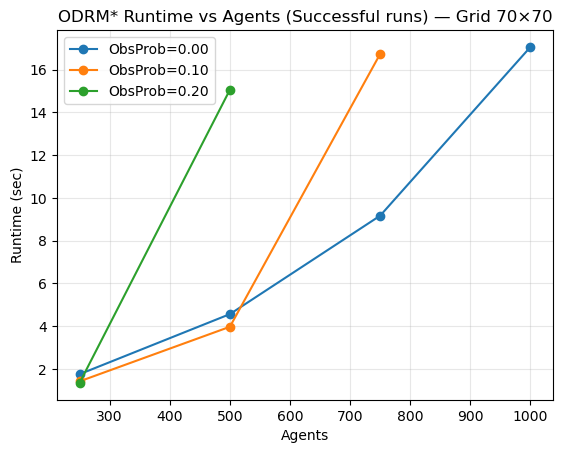

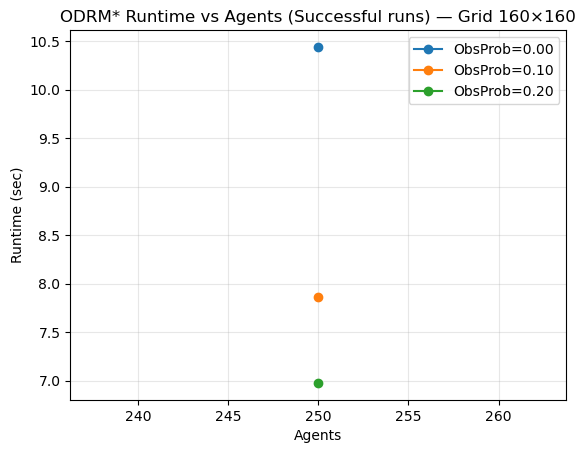

In [14]:
def plot_runtime(df_sub: pd.DataFrame, grid: int):
    d = df_sub[(df_sub["grid"] == grid) & (df_sub["success"] == True)].copy()
    if d.empty:
        print(f"No successful runs to plot for grid={grid}.")
        return
    plt.figure()
    for obs in sorted(d["obs_prob"].unique()):
        dd = d[d["obs_prob"] == obs].sort_values("agents")
        plt.plot(dd["agents"], dd["runtime_sec"], marker="o", label=f"ObsProb={obs:.2f}")
    plt.title(f"ODRM* Runtime vs Agents (Successful runs) — Grid {grid}×{grid}")
    plt.xlabel("Agents")
    plt.ylabel("Runtime (sec)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_runtime(df, 70)
plot_runtime(df, 160)


In [15]:
def pivot_success(df_sub: pd.DataFrame, grid: int) -> pd.DataFrame:
    p = (df_sub[df_sub["grid"] == grid]
         .pivot_table(index="agents", columns="obs_prob", values="success", aggfunc="mean")
         .mul(100)
         .sort_index()
    )
    p.columns = [f"{c:.2f}" for c in p.columns]
    return p

succ_70 = pivot_success(df, 70)
succ_160 = pivot_success(df, 160)

print("Success rate (%) — 70x70")
display(succ_70)
print("\nSuccess rate (%) — 160x160")
display(succ_160)


Success rate (%) — 70x70


,0.00,0.10,0.20
agents,,,
250,100.0,100.0,100.0
500,100.0,100.0,100.0
750,100.0,100.0,0.0
1000,100.0,0.0,0.0



Success rate (%) — 160x160


,0.00,0.10,0.20
agents,,,
250,100.0,100.0,100.0
500,0.0,0.0,0.0
750,0.0,0.0,0.0
1000,0.0,0.0,0.0


In [16]:
# Failure reasons (counts)
fail_reasons = (df[df["success"] == False]["failure_reason"]
                .fillna("Unknown")
                .value_counts()
                .rename_axis("failure_reason")
                .reset_index(name="count"))
fail_reasons


,failure_reason,count
0,std::bad_alloc,12


## 6) Interpretation: what the data says

### Where ODRM\* looks strong
- **Small-to-mid scale** (e.g., 70×70 up to ~500 agents) typically succeeds and produces reasonable step counts.
- At 70×70 with low obstacle probability, runtime rises with agent count in a *predictable* way (more agents → more coordination).

### The key scalability drawback: memory failures
The dominant failure mode in the logs is `std::bad_alloc`, which indicates an **allocation failure** — commonly caused by **running out of available memory** (or failing to allocate a contiguous block). In practice, this shows up as:

- Increasing **agents** pushes memory usage up (e.g., data structures for multi-agent search/constraints).
- Increasing **grid size** expands the state space and typically multiplies memory needs.

### Why this matters
Even if runtimes look acceptable *before* the cliff, the **OOM cliff** means:

- The planner becomes **unreliable** in larger deployments: it doesn’t just get slower, it **fails outright**.
- For larger grids (160×160), failures appear already at **500 agents** across obstacle settings — suggesting a **hard memory ceiling** under the tested configuration.
- For 70×70, the boundary is softer (e.g., some runs still succeed at 1000 agents with 0% obstacles), but OOM appears quickly as obstacles increase.

**Bottom line:** ODRM\* can be compelling for controlled/smaller scenarios, but the out-of-memory failure trend is a critical drawback that limits practical scalability unless memory usage is reduced (algorithmic changes) or the system is provisioned with substantially more RAM.
